<a href="https://colab.research.google.com/github/ngthiagpgp/Curso-de-Avalia-o-de-Pol-ticas-P-blicas/blob/main/Aula_Quartiles_e_GAM_r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantile Regression & GAM

Público: Pós-graduação em Economia

Pré-requisitos: OLS, noções de inferência, R básico

## Objetivos de Aprendizagem

Entender quando e por que OLS não basta (heterocedasticidade, caudas, não linearidades).


1.   Entender quando e por que OLS não basta (heterocedasticidade, caudas, não linearidades).
2.   Estimar e interpretar Regressão Quantílica (múltiplos quantis).
3.   Estimar e interpretar GAM para capturar não linearidades.

4. Comparar métodos e justificar escolhas em problemas aplicados.

## Pacotes
Para a nossa aula, vamos utilizar alguns pacotes do R que facilitam a implementação dos métodos discutidos:

**ggplot2**: pacote central para visualização de dados em R. Será usado para gerar gráficos de dispersão, linhas de regressão e comparações entre modelos.

**quantreg**: pacote que implementa a regressão quantílica proposta por Koenker e Bassett (1978). Permite estimar diferentes quantis condicionais da distribuição da variável dependente, indo além da média condicional do OLS.

**mgcv**: pacote desenvolvido por Simon Wood para estimação de Modelos Aditivos Generalizados (GAM). Ele utiliza funções de suavização para capturar relações não lineares entre variáveis.

**ISLR**: pacote que acompanha o livro An Introduction to Statistical Learning. Ele contém diversos bancos de dados prontos para prática; em nossa aula, utilizaremos o dataset Wage, que traz informações sobre salários e características individuais de trabalhadores.

Também fixamos uma semente aleatória com set.seed(1) para garantir a reprodutibilidade dos resultados, ou seja, que todos vejam os mesmos números e gráficos ao rodar o código.

In [21]:
install.packages("quantreg")
install.packages("mgcv")
install.packages("ISLR")
# Pacotes
library(ggplot2)
library(quantreg)
library(mgcv)
library(ISLR)      # para o dataset Wage

# Semente global
set.seed(1)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘SparseM’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: SparseM

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.



## 1) Por que ir além do OLS?
OLS: estima a média condicional
𝐸[𝑦∣𝑥] e assume forma linear e, para eficiência, homocedasticidade.
Limitações:

**Heterocedasticidade** → variância depende de 𝑥.

**Interesse em caudas** → média ignora heterogeneidade nos quantis.

**Não linearidade** → relação não é bem descrita por reta.

### Visualização inicial (dados simulados)

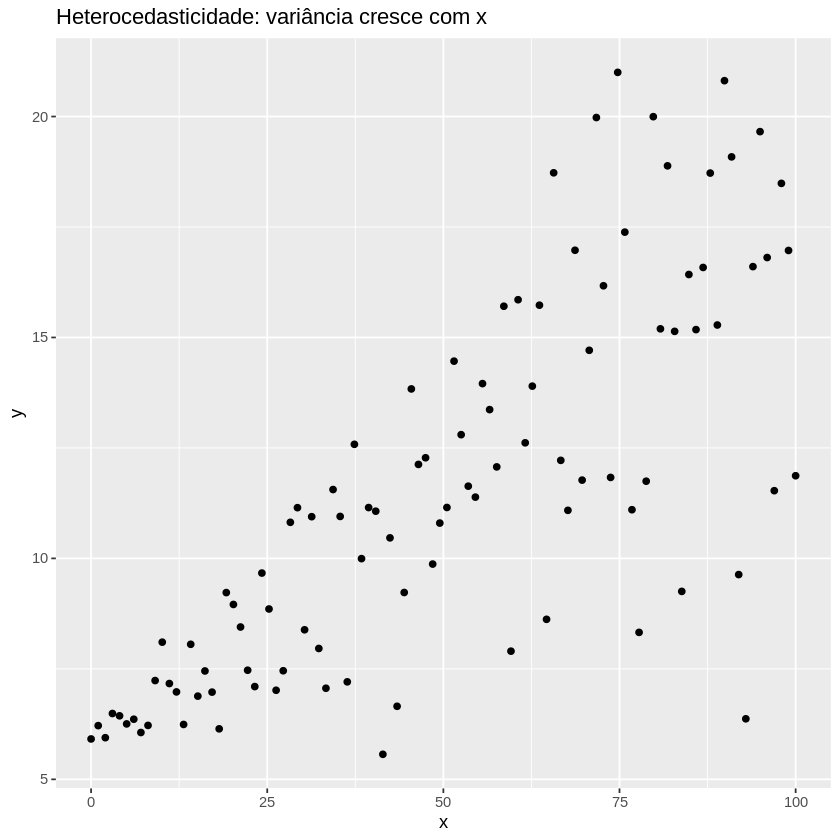

In [6]:
# Simulação com variância não constante
x  <- seq(0, 100, length.out = 100)
sig <- 0.1 + 0.05 * x
b0 <- 6; b1 <- 0.1
e  <- rnorm(100, mean = 0, sd = sig)
y  <- b0 + b1 * x + e
dat <- data.frame(x, y)

ggplot(dat, aes(x, y)) +
  geom_point() +
  labs(title = "Heterocedasticidade: variância cresce com x")

regressão linear tradicional (OLS) estima a média condicional de 𝑦 dado 𝑥.



Call:
lm(formula = y ~ x, data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.8205 -1.0940  0.0554  1.1719  6.8144 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 5.942971   0.547228   10.86   <2e-16 ***
x           0.110269   0.009454   11.66   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.757 on 98 degrees of freedom
Multiple R-squared:  0.5813,	Adjusted R-squared:  0.577 
F-statistic:   136 on 1 and 98 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'


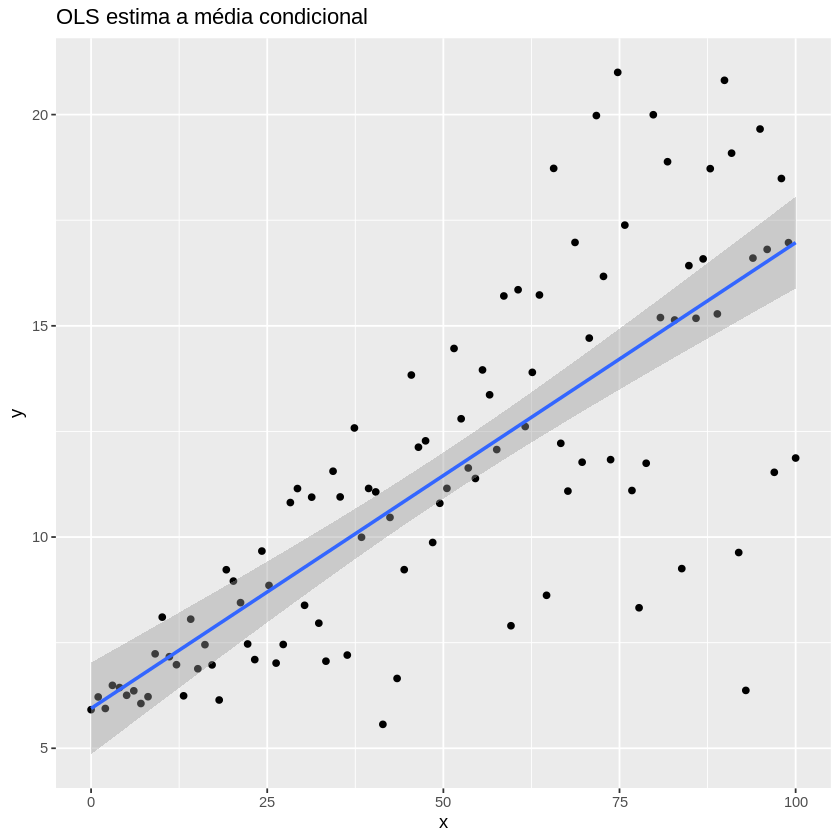

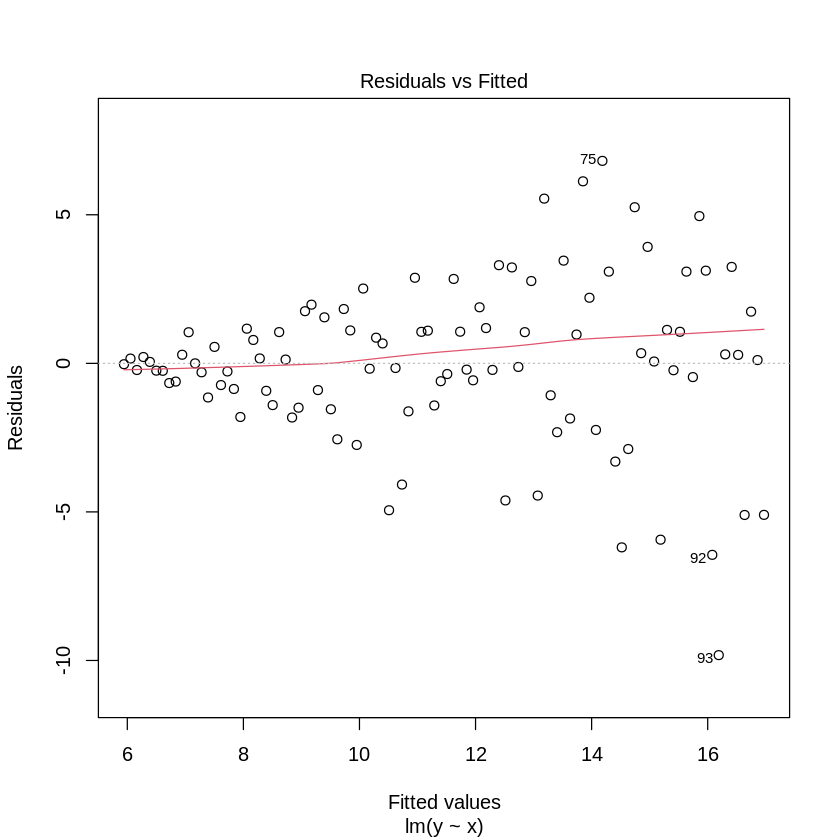

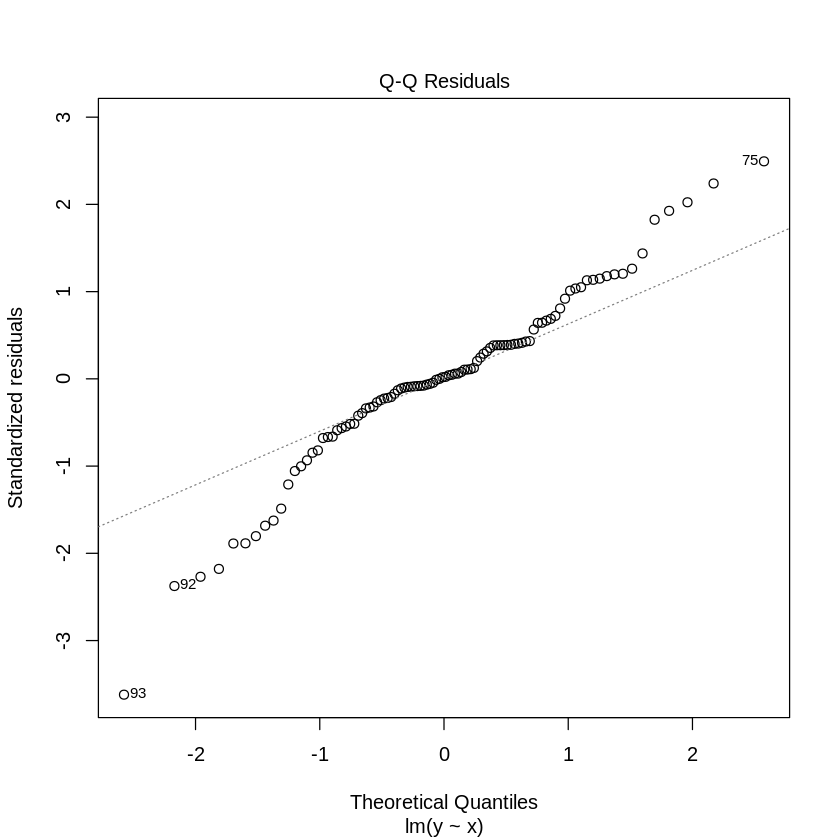

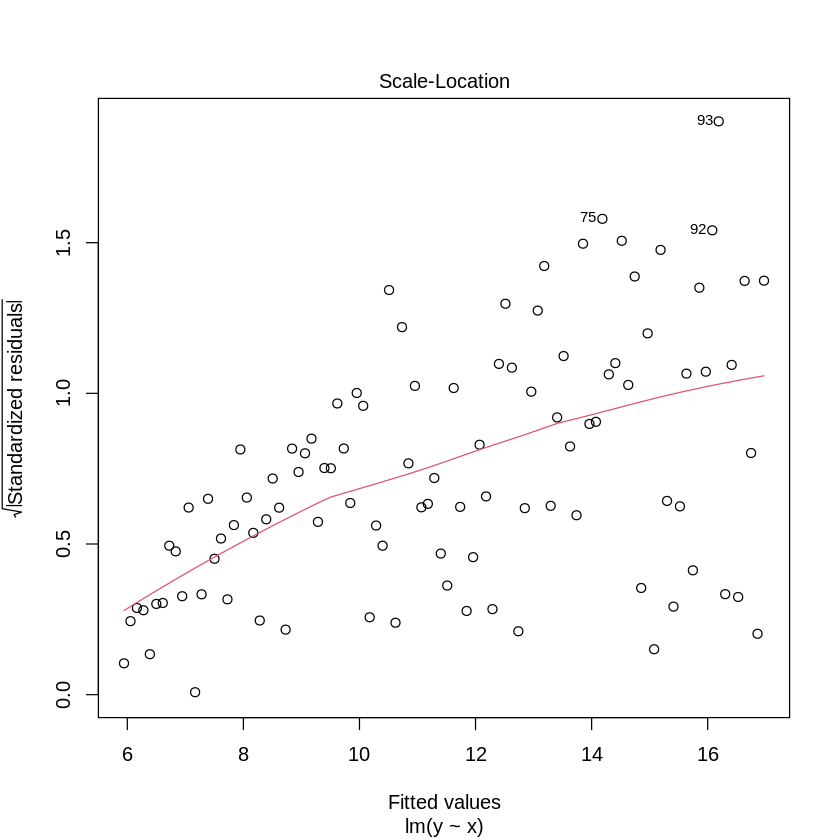

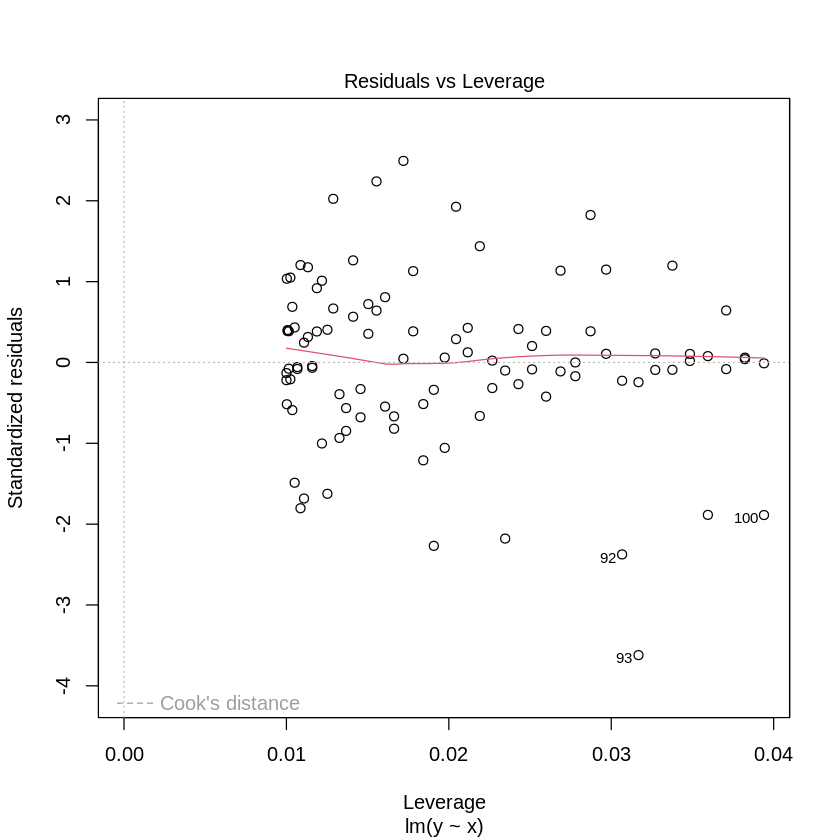

In [8]:
m_ols <- lm(y ~ x, data=dat)
summary(m_ols)
ggplot(dat, aes(x, y)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "OLS estima a média condicional")
plot(m_ols)

No entanto, quando a variância dos erros cresce com 𝑥 (heterocedasticidade), a reta de OLS não descreve bem a distribuição de pontos.

## Tentativa Ingênua: Análise por Quartis
Uma abordagem comum é estratificar os dados em quartis de 𝑦 e rodar OLS em cada subconjunto.



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


`geom_smooth()` using formula = 'y ~ x'


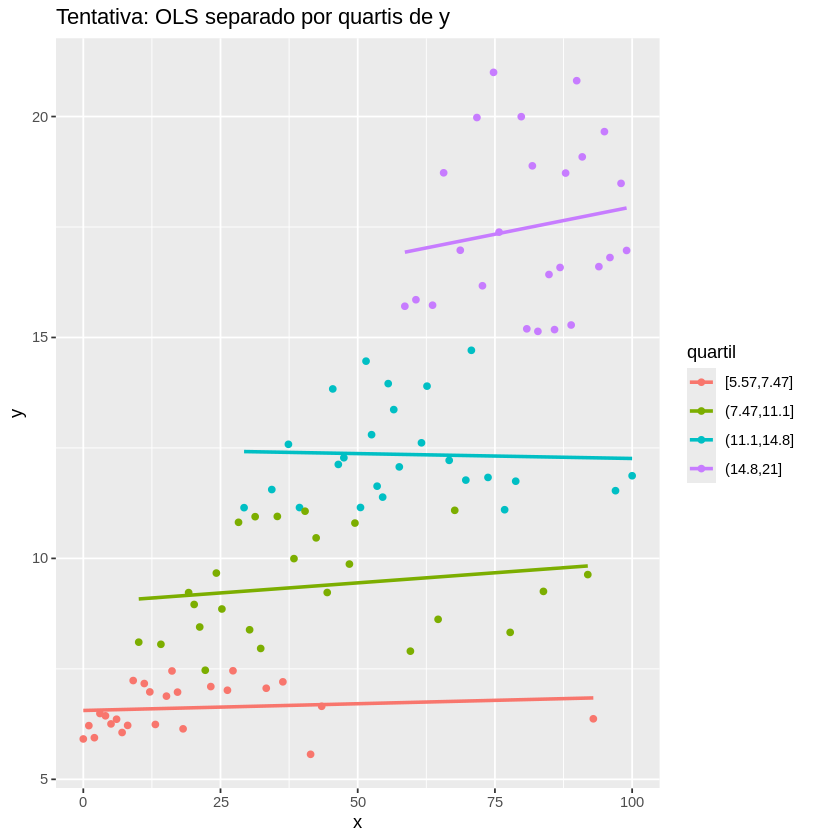

In [9]:
# Criar quartis de y
dat$quartil <- cut(dat$y,
                   breaks = quantile(dat$y, probs = seq(0,1,0.25)),
                   include.lowest = TRUE)

# Rodar OLS separado por quartil
models_quartis <- by(dat, dat$quartil, function(subdat) {
  lm(y ~ x, data = subdat)
})

# Visualizar retas por quartil
library(dplyr)
ggplot(dat, aes(x, y, color = quartil)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Tentativa: OLS separado por quartis de y")


Isso gera algumas retas diferentes, mas traz problemas:

- Cada regressão usa subamostras diferentes, o que muda a composição do grupo.

- Não controla pelas covariáveis ao mesmo tempo.

- O resultado não é o quantil condicional, mas apenas uma comparação entre grupos arbitrários.

# 2) Regressão Quantílica (QR)

## 2.1 Conceito

Estima o quantil condicional
𝑄𝑦(𝜏∣𝑥)=𝑥′𝛽(𝜏)

𝜏 = 0.5 → mediana condicional (robusta a outliers).

𝜏 baixos/altos → caudas (vulneráveis/topo).
## 2.2 Intuição Gráfica

`geom_smooth()` using formula = 'y ~ x'
Smoothing formula not specified. Using: y ~ x


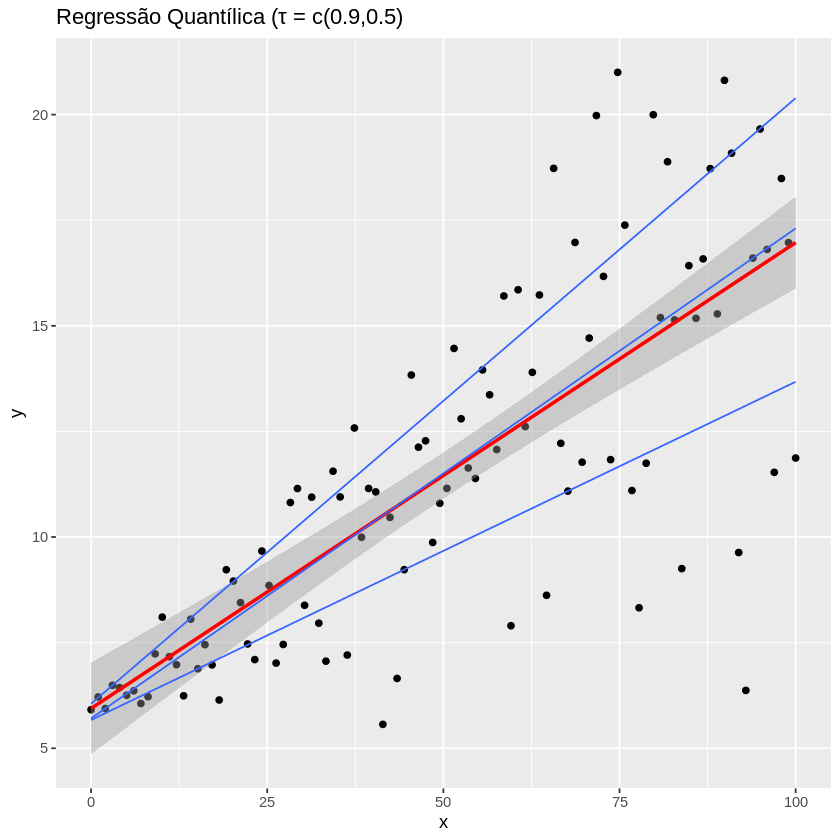

In [35]:


# Uma reta quantílica (tau = 0.9)
ggplot(dat, aes(x, y)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE,col="red") +
  geom_quantile(quantiles = c(0.75,0.5,0.25)) +

  labs(title = "Regressão Quantílica (τ = c(0.9,0.5)")


## 2.3 Estimando com quantreg

Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”



Call: rq(formula = y ~ x, tau = 0.9, data = dat)

tau: [1] 0.9

Coefficients:
            coefficients lower bd upper bd
(Intercept) 6.01349      5.97621  6.14976 
x           0.17503      0.16234  0.18198 

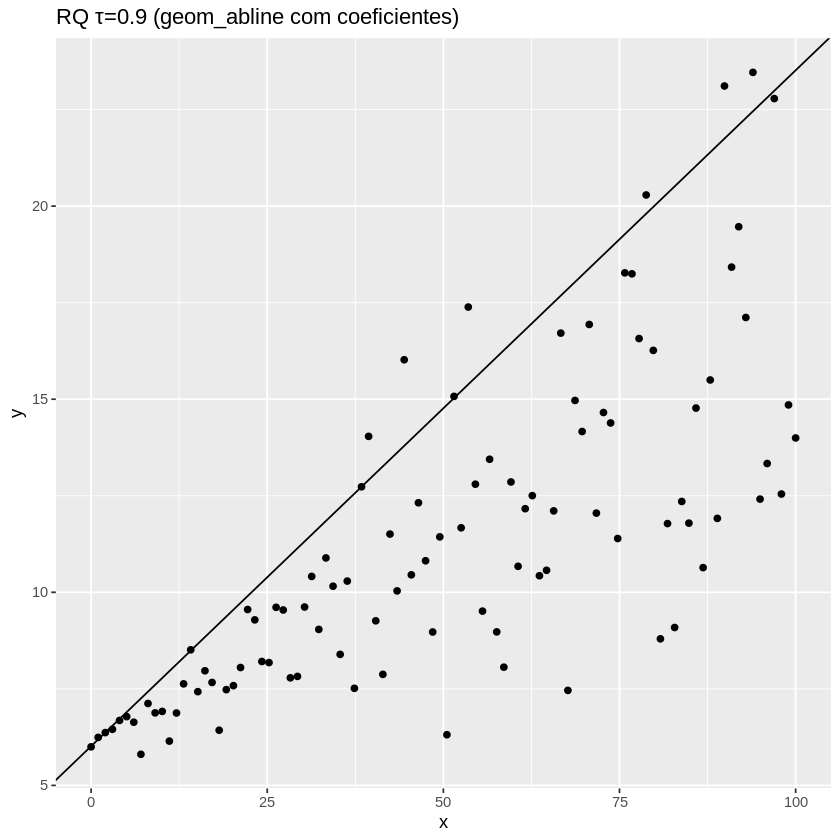

In [ ]:
# Um quantil
qr_90 <- rq(y ~ x, data = dat, tau = 0.9)
summary(qr_90)

# Desenhar a reta do τ=0.9 explicitamente
ggplot(dat, aes(x, y)) +
  geom_point() +
  geom_abline(intercept = coef(qr_90)[1],
              slope     = coef(qr_90)[2]) +
  labs(title = "RQ τ=0.9 (geom_abline com coeficientes)")


## 2.4 Vários quantis

,tau= 0.1,tau= 0.2,tau= 0.3,tau= 0.4,tau= 0.5,tau= 0.6,tau= 0.7,tau= 0.8,tau= 0.9
(Intercept),5.48808100,6.00697850,6.2162965,6.18855638,6.0182828,6.1250836,6.0881699,6.0104498,6.0134917
x,0.05929832,0.06747013,0.0692545,0.08173749,0.1019419,0.1145543,0.1277506,0.1463852,0.1750331


Smoothing formula not specified. Using: y ~ x


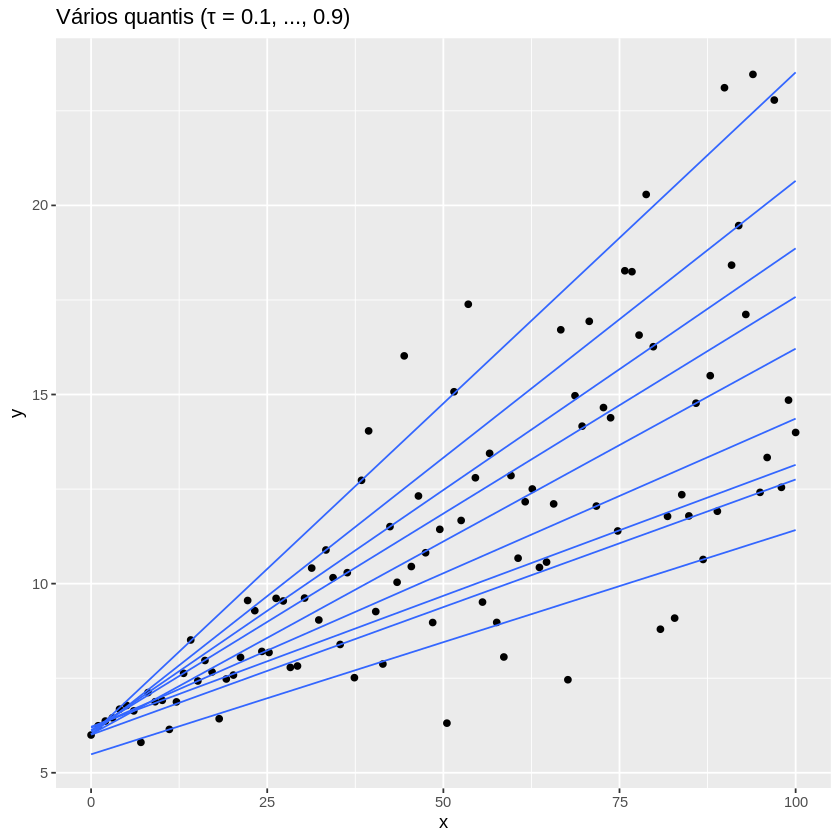

In [ ]:
taus <- 1:9 / 10
qr_all <- rq(y ~ x, data = dat, tau = taus)
coef(qr_all)

# Visual com múltiplos quantis
ggplot(dat, aes(x, y)) +
  geom_point() +
  geom_quantile(quantiles = taus) +
  labs(title = "Vários quantis (τ = 0.1, ..., 0.9)")


## 2.5 Diagnóstico/Resumo

Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”


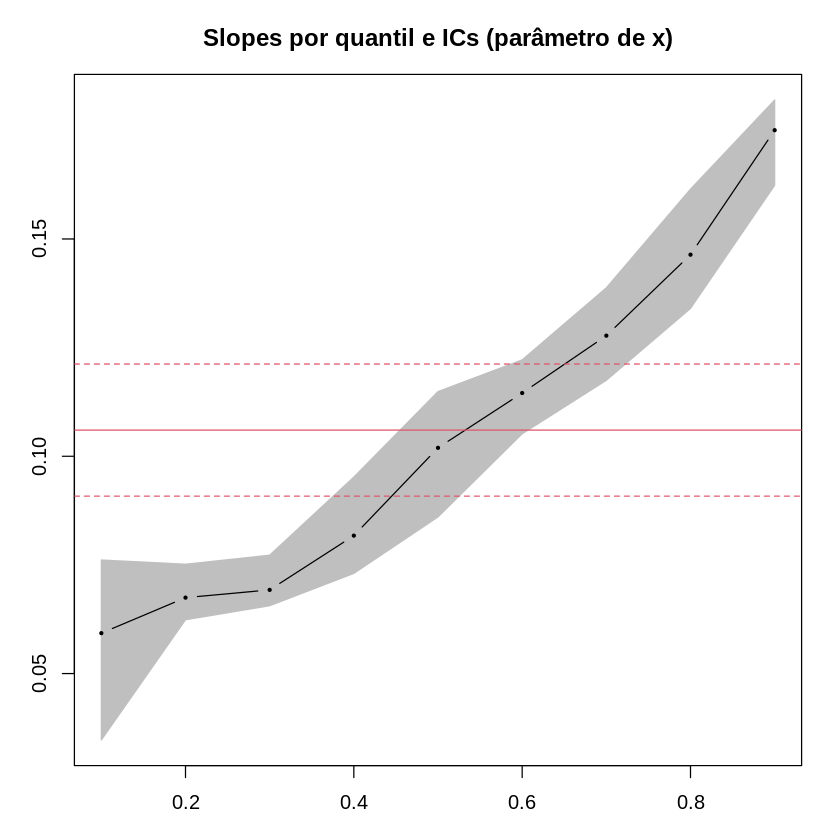

In [ ]:
# Teste visual: os slopes por quantil diferem? (indicando heterogeneidade)
plot(summary(qr_all), parm = "x",
     main = "Slopes por quantil e ICs (parâmetro de x)")


## 2.6 Caso com variância constante (benchmark)

Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”
Warning message in rq.fit.br(x, y, tau = tau, ci = TRUE, ...):
“Solution may be nonunique”


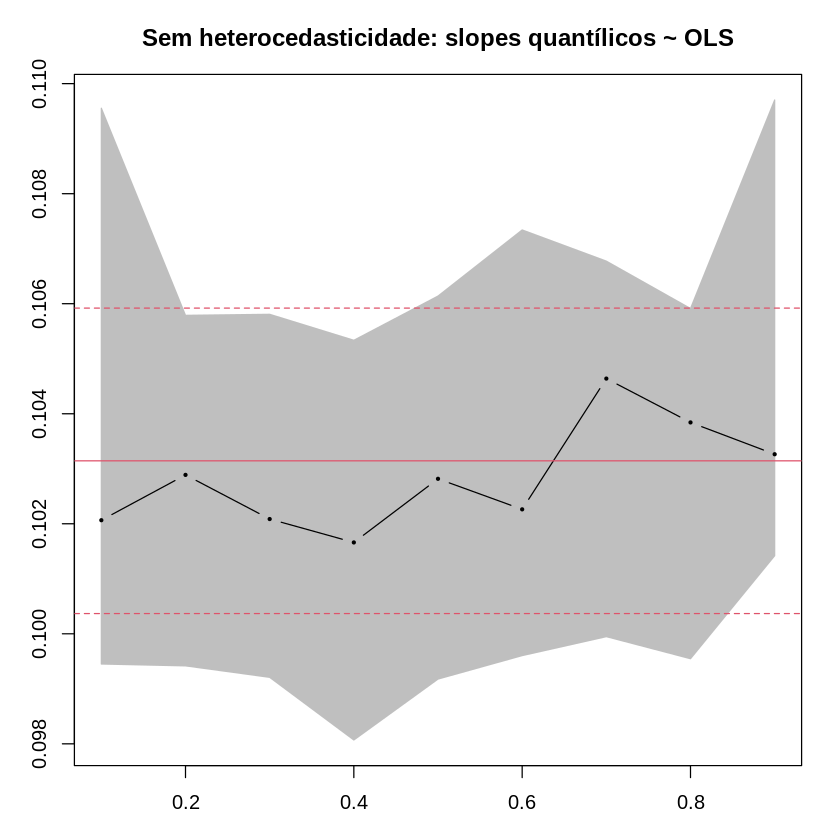

In [ ]:
# Agora erros com variância constante
x2 <- seq(0, 100, length.out = 100)
e2 <- rnorm(100, mean = 0, sd = 0.5)
y2 <- b0 + b1 * x2 + e2
dat2 <- data.frame(x = x2, y = y2)

qr_const <- rq(y ~ x, data = dat2, tau = taus)
plot(summary(qr_const), parm = "x",
     main = "Sem heterocedasticidade: slopes quantílicos ~ OLS")


Leitura: quando a variância é aproximadamente constante e os erros são simétricos, os slopes dos quantis tendem a ser próximos ao OLS.

Função Perda da Regressão Quantílica

A regressão quantílica minimiza a soma da função check (ou pinball loss):

$\rho_{\tau}(u) =
\begin{cases}
\tau \cdot u, & u \geq 0 \\
(\tau - 1) \cdot u, & u < 0
\end{cases}$

onde 𝑢=𝑦𝑖−𝑥𝑖′ é o resíduo, e  𝜏 τ é o quantil de interesse.

No OLS, erros grandes (positivos ou negativos) são penalizados quadraticamente: isso puxa a reta para o centro da nuvem de pontos → média condicional.
Na Regressão Quantílica, a penalização é linear e assimétrica:

- Para 𝜏 = 0.5, erros positivos e negativos têm peso igual

 → mediana condicional.

- Para  𝜏 = 0.9, erros positivos pesam mais

 → o modelo se ajusta de forma que 90% dos pontos fiquem abaixo da reta.

# 3) Exemplo Empírico – Renda x Tempo (e Sexo)
Objetivo: verificar se a evolução no tempo difere nos quantis de renda e entre sexos.
Atenção: Substitua income.csv pelo seu arquivo (colunas: YEAR, INCTOT, SEX), se desejar replicar o script original.

,X,SEX,AGE,EDUC,INCTOT,NOHS,HS,SOME,BS,MS,PROFESS,PHD,YEAR
,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,1,28,13,20000,0,0,0,1,0,0,0,2000
2,2,1,45,5,30000,1,0,0,0,0,0,0,2000
3,3,1,42,11,37700,0,0,1,0,0,0,0,2000
4,4,1,24,11,-10000,0,0,1,0,0,0,0,2000
5,5,2,22,1,13000,1,0,0,0,0,0,0,2000
6,6,2,75,5,4800,1,0,0,0,0,0,0,2000


       X                SEX             AGE             EDUC      
 Min.   :      1   Min.   :1.000   Min.   :22.00   Min.   : 1.00  
 1st Qu.: 216838   1st Qu.:1.000   1st Qu.:36.00   1st Qu.: 9.00  
 Median : 479123   Median :2.000   Median :48.00   Median :11.00  
 Mean   : 486889   Mean   :1.526   Mean   :49.61   Mean   :11.38  
 3rd Qu.: 750674   3rd Qu.:2.000   3rd Qu.:62.00   3rd Qu.:13.00  
 Max.   :1000000   Max.   :2.000   Max.   :95.00   Max.   :24.00  
     INCTOT             NOHS              HS              SOME       
 Min.   : -19998   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:   9300   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :  22750   Median :0.0000   Median :0.0000   Median :0.0000  
 Mean   :  34356   Mean   :0.1639   Mean   :0.2949   Mean   :0.2788  
 3rd Qu.:  43000   3rd Qu.:0.0000   3rd Qu.:1.0000   3rd Qu.:1.0000  
 Max.   :1338000   Max.   :1.0000   Max.   :1.0000   Max.   :1.0000  
       BS               MS             PR

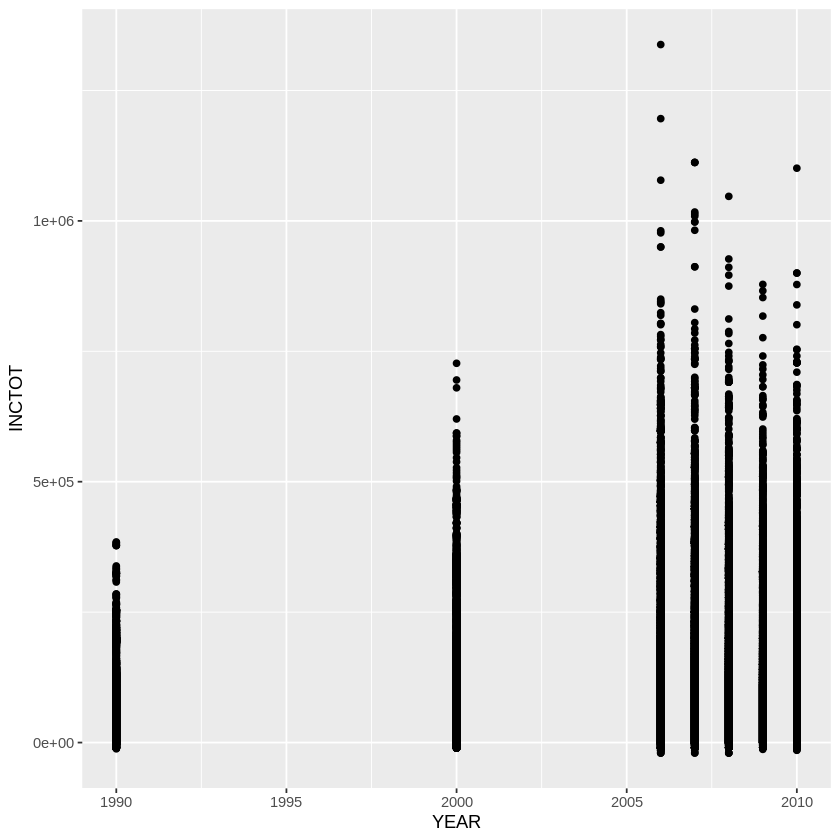

In [37]:
# Exemplo: se tiver o arquivo, descomente:
income <- read.csv("income.csv")
head(income); summary(income)

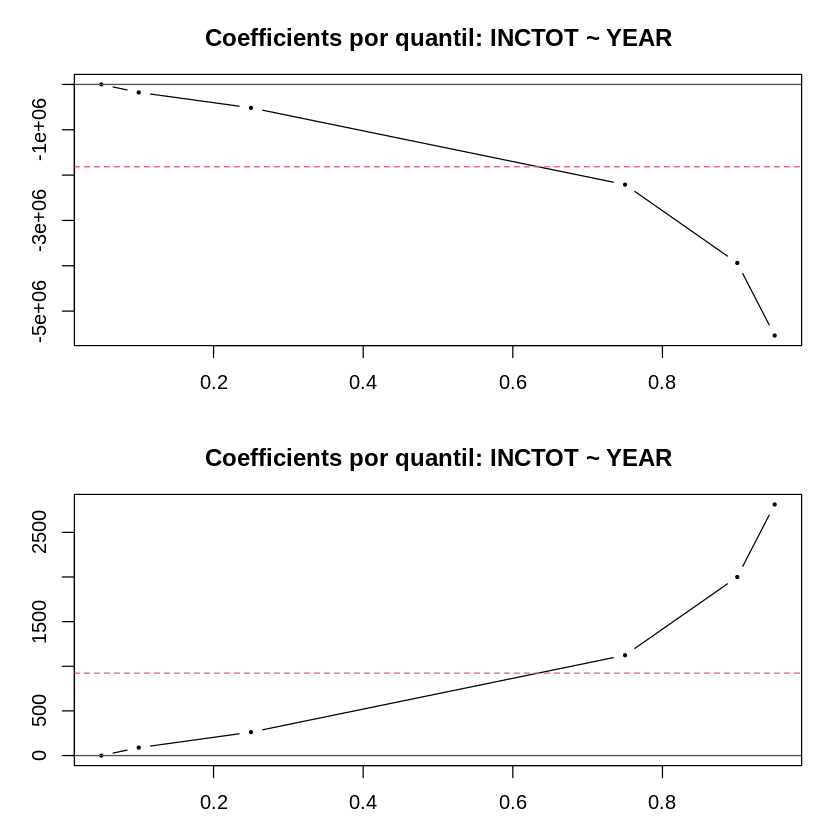

In [ ]:
# taus de interesse
taus <- c(.05,.1,.25,.75,.9,.95)

# Modelo geral por quantis
mod <- rq(INCTOT ~ YEAR, tau = taus, data = income, method = "fn")
plot(mod, main = "Coefficients por quantil: INCTOT ~ YEAR")


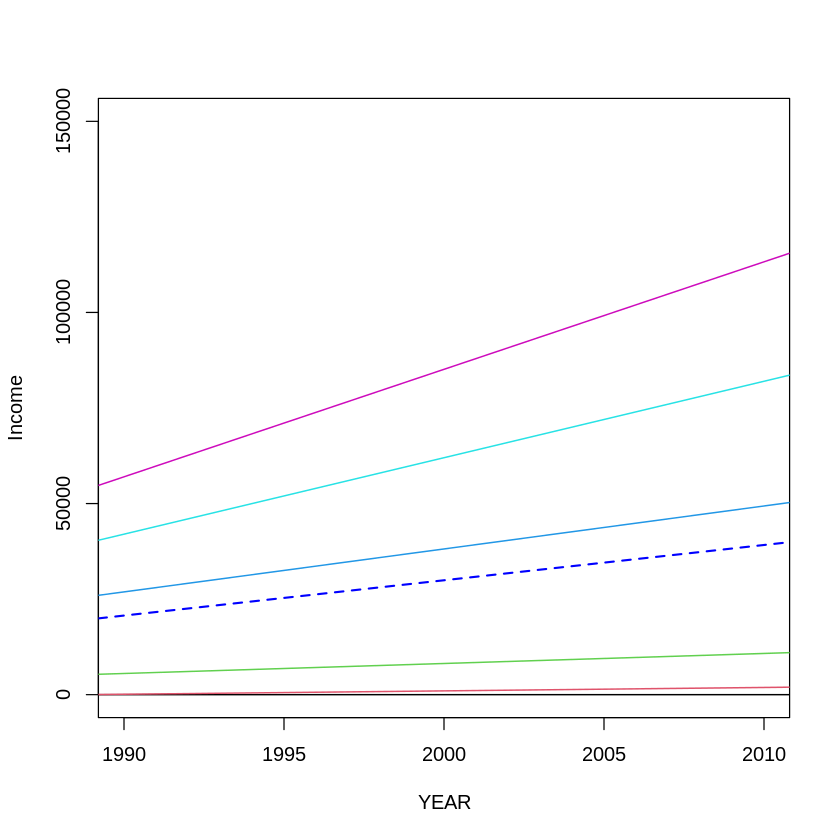

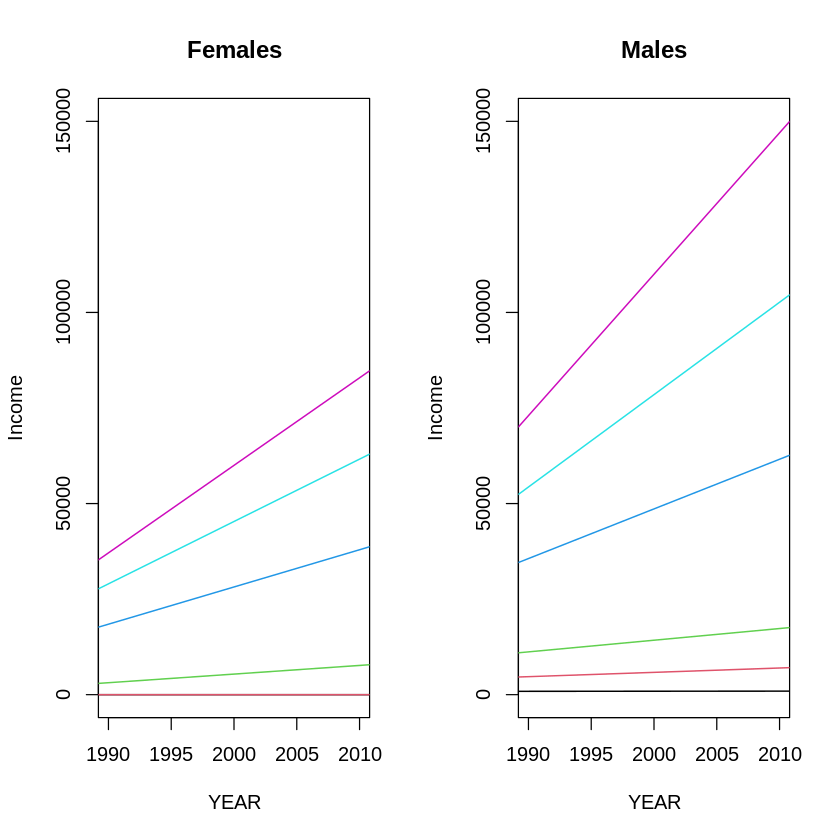

In [ ]:

# Visual comparando retas quantílicas e OLS (baseline)
 plot(income$YEAR, income$INCTOT, xlab = "YEAR", ylab = "Income", pch = '',ylim=c(0,150000))
 for (i in seq_along(taus)) abline(mod$coefficients[, i], col = i, lwd = 1.2)
 abline(lm(INCTOT ~ YEAR, data = income), col = "blue", lty = 2, lwd = 1.7)

# Estratificado por SEX (1=male, 2=female)
 mod_f <- rq(INCTOT ~ YEAR, tau = taus, method = "fn", data = income, subset = (SEX == 2))
 mod_m <- rq(INCTOT ~ YEAR, tau = taus, method = "fn", data = income, subset = (SEX == 1))

 par(mfrow = c(1,2))
 plot(income$YEAR, income$INCTOT, xlab = "YEAR", ylab = "Income", pch = '',ylim=c(0,150000))
 for (i in seq_along(taus)) abline(mod_f$coefficients[, i], col = i, lwd = 1.2)
 title(main = "Females")

 plot(income$YEAR, income$INCTOT, xlab = "YEAR", ylab = "Income", pch = '',ylim=c(0,150000))
 for (i in seq_along(taus)) abline(mod_m$coefficients[, i], col = i, lwd = 1.2)
 title(main = "Males")

# Exemplo 3 - Faça você mesmo - Este será o Trabalho 2
Use um banco de dados seu (ex., da sua própria pesquisa) e aplique a OLS regression e o quantile regression.

 Em seguida, responda as seguintes perguntas:

## A OLS regression é o suficiente para captar a relação entre y e x? Justifique sua resposta.

## O quantile regression é útil para as suas análises?




# 4) GAM – Generalized Additive Models
## 4.1 Definições
 - OLS/QR assumem linearidade em 𝑥.
 - Se a relação é não linear, GAM estima $𝐸[𝑦∣𝑥]=𝛽_0 +𝑓(𝑥)$ com 𝑓(⋅) suave (splines + penalização).
 - Estimação por penalização:

  - $\min_{f} \left\{ \sum_{i=1}^{n} \big(y_i - f(x_i)\big)^2 \;+\; \lambda \int \big(f''(x)\big)^2 \, dx \right\}
$

 onde λ controla o grau de suavização (trade-off entre ajuste e parcimônia).


## O que é uma Spline?
Uma spline é uma função construída a partir de polinômios por partes, unidos em pontos chamados knots (nós).

Em cada intervalo definido pelos knots, ajusta-se um polinômio (geralmente de baixo grau, como linear ou cúbico).

Esses polinômios são colados de modo a garantir continuidade e, em geral, suavidade (derivadas iguais nas junções).

O resultado é uma curva flexível, mas suave, que consegue capturar não linearidades sem oscilar excessivamente como acontece com polinômios de alto grau.


## 4.2 Exemplo Simulado (seno)

`geom_smooth()` using formula = 'y ~ x'


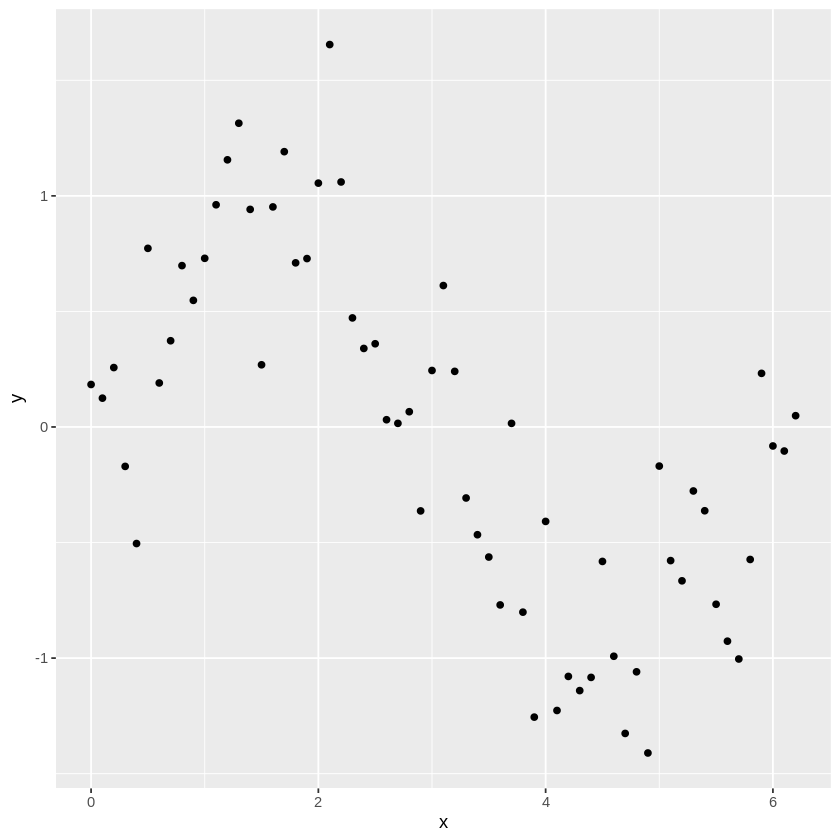

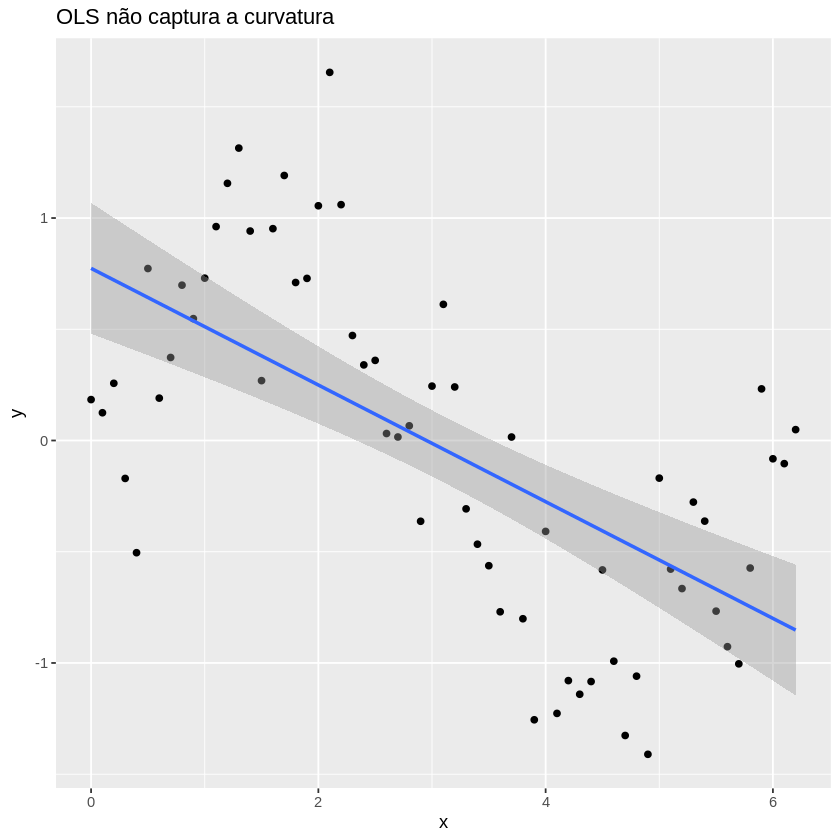

`geom_smooth()` using formula = 'y ~ x'


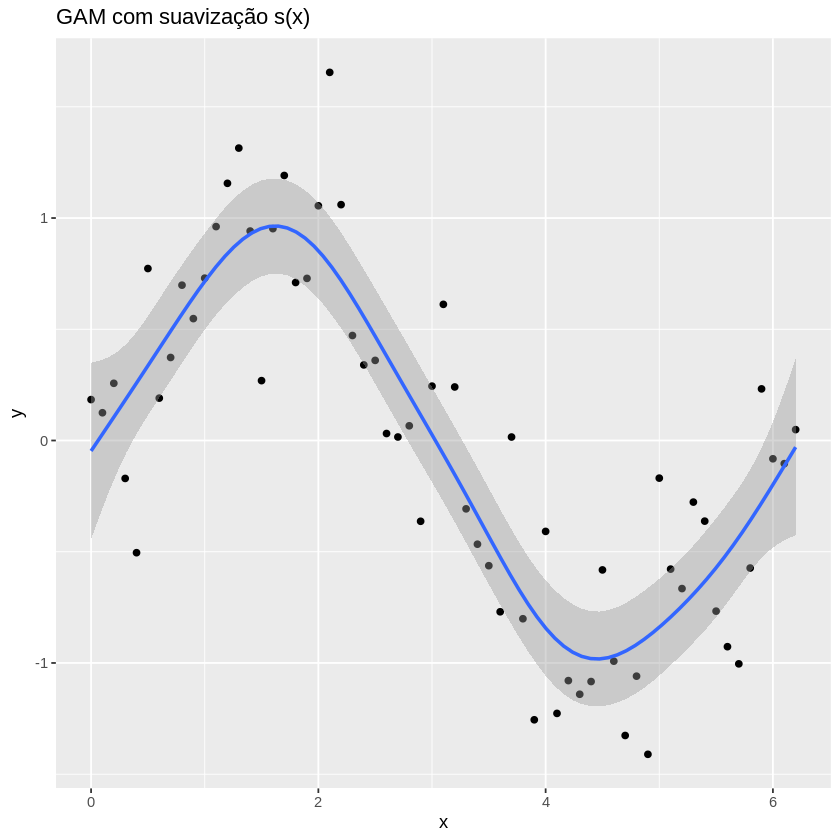

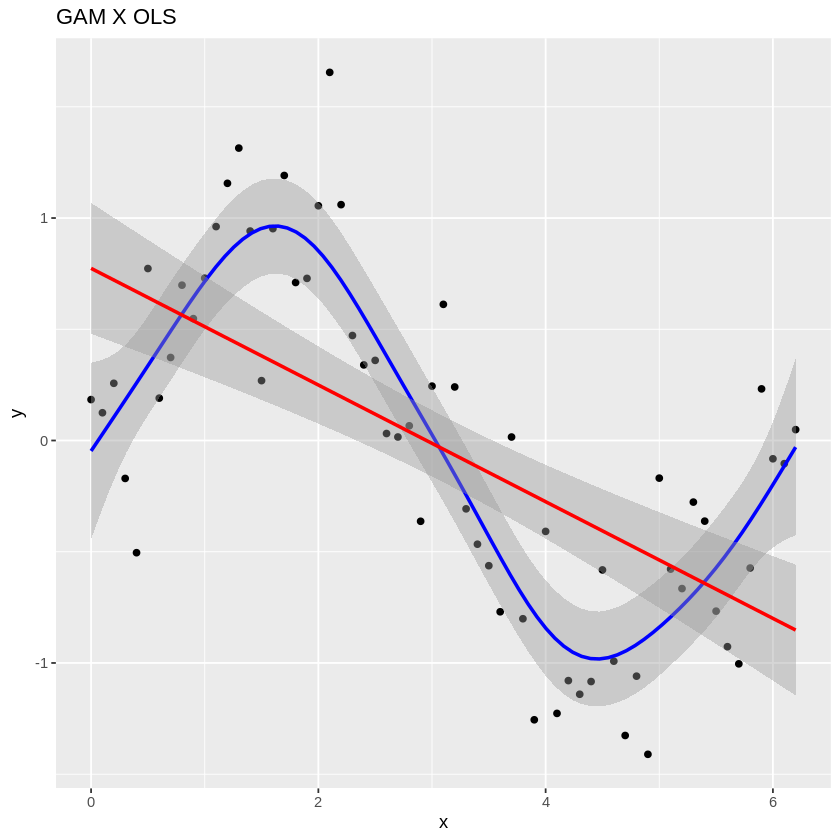

In [ ]:
# Relação não linear
x  <- seq(0, 2*pi, 0.1)
sin_x <- sin(x)
y  <- sin_x + rnorm(n = length(x), mean = 0, sd = sd(sin_x / 2))
Sample_data <- data.frame(y, x)

# Visual
ggplot(Sample_data, aes(x, y)) + geom_point()

# OLS
lm_y <- lm(y ~ x, data = Sample_data)
ggplot(Sample_data, aes(x, y)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "OLS não captura a curvatura")

# GAM
gam_y <- gam(y ~ s(x), method = "REML")
ggplot(Sample_data, aes(x, y)) +
  geom_point() +
  geom_smooth(method = "gam", formula = y ~ s(x)) +
  labs(title = "GAM com suavização s(x)")

# tudo junto:

ggplot(Sample_data, aes(x, y)) +
  geom_point() +
  geom_smooth(method = "gam", formula = y ~ s(x),col="blue") +
  geom_smooth(method = "lm", se = TRUE,col="red") +
  labs(title = "GAM X OLS")

gam.check avalia ajuste e suavidade.

summary reporta EDF (graus de liberdade efetivos): maior EDF → curva mais flexível.


Method: REML   Optimizer: outer newton
full convergence after 6 iterations.
Gradient range [-5.885973e-09,5.154296e-09]
(score 35.35849 & scale 0.1313409).
Hessian positive definite, eigenvalue range [2.053177,30.6975].
Model rank =  10 / 10 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

       k'  edf k-index p-value
s(x) 9.00 5.74    0.88    0.18



Family: gaussian 
Link function: identity 

Formula:
y ~ s(x)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.03914    0.04566  -0.857    0.395

Approximate significance of smooth terms:
       edf Ref.df     F p-value    
s(x) 5.741  6.895 30.37  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.771   Deviance explained = 79.2%
-REML = 35.358  Scale est. = 0.13134   n = 63

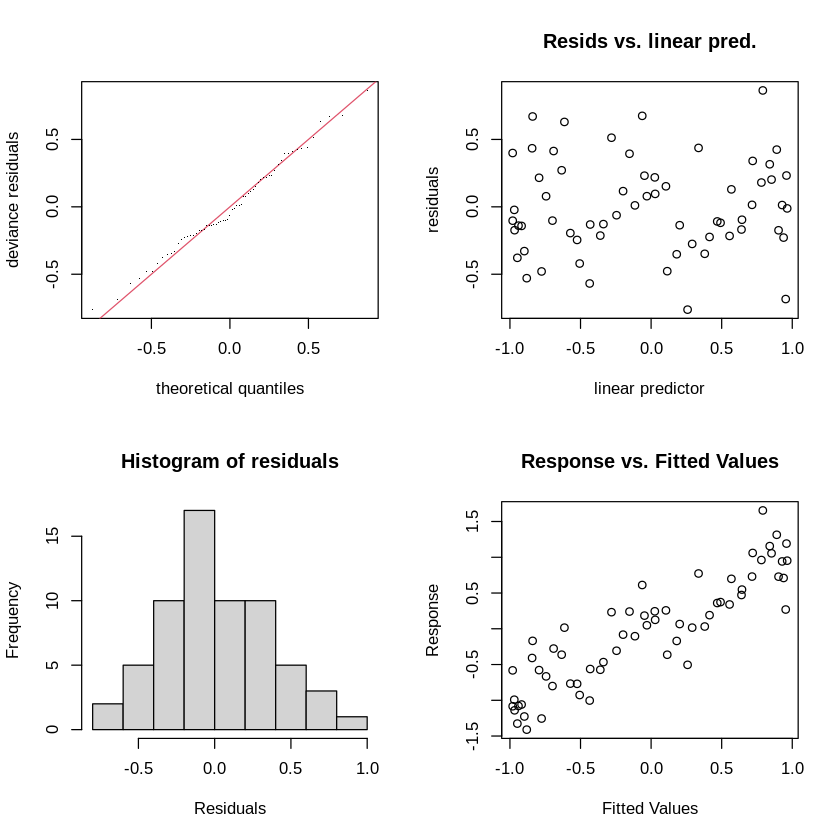

In [ ]:
# Diagnósticos
par(mfrow = c(2,2))
gam.check(gam_y)
summary(gam_y)
par(mfrow = c(1,1))

## 4.3 Exemplo com dados reais – Wage (ISLR)


Family: gaussian 
Link function: identity 

Formula:
wage ~ s(age)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 111.7036     0.7282   153.4   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df     F p-value    
s(age) 5.534  6.642 42.89  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.0864   Deviance explained = 8.81%
-REML =  15319  Scale est. = 1590.8    n = 3000

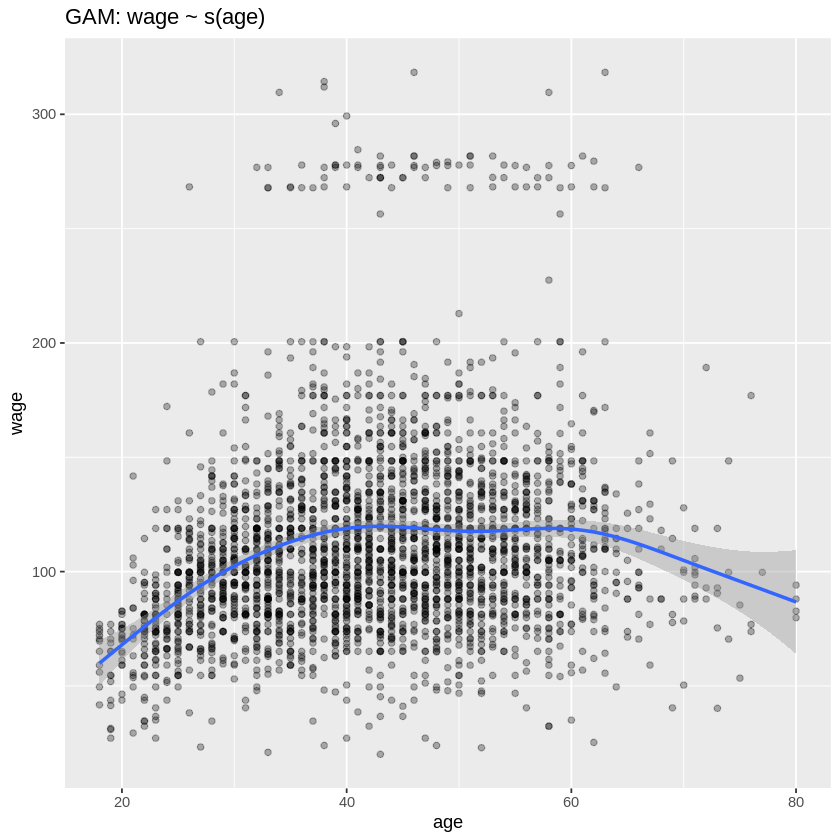

In [ ]:
data(Wage)
df <- Wage

# Ex.: tendência temporal (se houvesse 'year' formal). Em Wage há 'year' implícito no recorte da amostra.
# Usaremos uma relação não linear típica: wage ~ s(age)
m1 <- gam(wage ~ s(age), data = df, method = "REML")
summary(m1)

# Visual
ggplot(df, aes(age, wage)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "gam", formula = y ~ s(x)) +
  labs(title = "GAM: wage ~ s(age)")
